In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [ ]:
# ==========================================================
# STEP 4: LOAD DATASETS
#
# Purpose:
#   Load all CSV files into Pandas DataFrames.
#   These datasets will be used throughout the analysis.
#
# Datasets:
#   - Inventory
#   - Sales
#   - Products
#   - Suppliers
#   - Warehouses
#   - Purchase Orders
# ==========================================================

inventory = pd.read_csv("../data/inventory.csv")
sales = pd.read_csv("../data/sales.csv")
products = pd.read_csv("../data/products.csv")
suppliers = pd.read_csv("../data/suppliers.csv")
warehouses = pd.read_csv("../data/warehouses.csv")
purchase = pd.read_csv("../data/purchase_orders.csv")

In [45]:
# ==========================================================
# STEP 5: INITIAL DATA INSPECTION
#
# Purpose:
#   Gain an initial understanding of the dataset before
#   performing any cleaning or analysis.
#
# We will examine:
#   - First few records
#   - Dataset structure
#   - Summary statistics
#   - Number of rows & columns
#   - Column names
# ==========================================================
purchase.head()


,PO_ID,Supplier_ID,SKU,Order_Qty,Received_Qty,Lead_Time,Delay_Days
0,PO000001,SUP029,SKU0663,481,464,3,6
1,PO000002,SUP024,SKU0795,442,422,12,3
2,PO000003,SUP006,SKU0723,471,462,10,0
3,PO000004,SUP009,SKU0347,194,188,6,4
4,PO000005,SUP002,SKU0181,113,100,14,1


In [21]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PO_ID         12000 non-null  object
 1   Supplier_ID   12000 non-null  object
 2   SKU           12000 non-null  object
 3   Order_Qty     12000 non-null  int64 
 4   Received_Qty  12000 non-null  int64 
 5   Lead_Time     12000 non-null  int64 
 6   Delay_Days    12000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 656.4+ KB


In [22]:
purchase.describe()

,Order_Qty,Received_Qty,Lead_Time,Delay_Days
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,259.490083,249.458083,7.979167,3.985083
std,138.590006,138.753532,3.758889,2.568413
min,20.000000,1.000000,2.000000,0.000000
25%,141.000000,131.000000,5.000000,2.000000
50%,260.000000,250.000000,8.000000,4.000000
75%,379.000000,369.000000,11.000000,6.000000
max,500.000000,499.000000,14.000000,8.000000


In [23]:
purchase.shape

(12000, 7)

In [24]:
purchase.columns

Index(['PO_ID', 'Supplier_ID', 'SKU', 'Order_Qty', 'Received_Qty', 'Lead_Time',
       'Delay_Days'],
      dtype='object')

# Business Problem

RetailMart Malaysia is experiencing increasing inventory costs while frequent stock-out issues continue to occur.

Management has requested an inventory analysis to identify operational inefficiencies and improve inventory management.

## Objectives

- Identify products that require immediate replenishment.
- Detect overstocked and slow-moving inventory.
- Evaluate warehouse inventory distribution.
- Assess supplier performance.
- Provide actionable business recommendations to improve inventory efficiency.

In [ ]:
# ==========================================================
# STEP 7: DATA QUALITY ASSESSMENT
#
# Purpose:
#   Evaluate the overall quality of the dataset before
#   performing any data cleaning.
#
# We will check:
#   - Missing values
#   - Duplicate records
#   - Data types
#   - Number of unique values
# ==========================================================

# Count missing values in each column
purchase.isnull().sum()
# Count duplicate rows
inventory.duplicated().sum()
# Display the data type of each column
inventory.dtypes
# Count unique values in each column
inventory.nunique()

PO_ID           0
Supplier_ID     0
SKU             0
Order_Qty       0
Received_Qty    0
Lead_Time       0
Delay_Days      0
dtype: int64

In [40]:
# ==========================================================
# STEP 8: CHECK DATASET SIZE & DUPLICATE RECORDS
# Purpose:
#   Understand the size of each dataset and identify
#   duplicate records before starting data cleaning.
# ==========================================================

# Store all datasets inside a dictionary
# Key = dataset name
# Value = dataframe
datasets = {
    "Inventory": inventory,
    "Sales": sales,
    "Products": products,
    "Suppliers": suppliers,
    "Warehouses": warehouses,
    "Purchase Orders": purchase
}

# Loop through every dataframe
for name, df in datasets.items():

    print(f"\n{name}")

    # Display number of rows and columns
    print("Dataset Shape:", df.shape)

    # Count duplicate rows
    print("Duplicate Records:", df.duplicated().sum())

    print("-" * 40)


Inventory
Dataset Shape: (10050, 8)
Duplicate Records: 50
----------------------------------------

Sales
Dataset Shape: (25000, 7)
Duplicate Records: 0
----------------------------------------

Products
Dataset Shape: (1000, 6)
Duplicate Records: 0
----------------------------------------

Suppliers
Dataset Shape: (30, 4)
Duplicate Records: 0
----------------------------------------

Warehouses
Dataset Shape: (8, 2)
Duplicate Records: 0
----------------------------------------

Purchase Orders
Dataset Shape: (12000, 7)
Duplicate Records: 0
----------------------------------------


In [55]:
# ==========================================================
# STEP 9: REMOVE DUPLICATE RECORDS
# Purpose:
#   Create a clean version of the inventory dataset
#   by removing duplicated rows.
# ==========================================================

# Remove duplicate rows
inventory_clean = inventory.drop_duplicates().copy()

# Display dataset size after cleaning
inventory_clean.shape

# Direct way to change original dataset
# inventory.drop_duplicates(inplace=True)

(10000, 8)

In [52]:
# ==========================================================
# STEP 10: CHECK MISSING VALUES IN INVENTORY DATA
#
# Purpose:
#   Identify columns with missing values before deciding
#   the appropriate cleaning strategy.
#
# Expected Output:
#   Number of missing values for each column.
# ==========================================================

inventory_clean.isnull().sum()

Date              0
Warehouse         0
SKU               0
Current_Stock    13
Reorder_Level     0
Max_Stock         0
Damaged_Qty       0
Holding_Cost      0
dtype: int64

In [56]:
# ==========================================================
# STEP 11: HANDLE MISSING VALUES IN CURRENT STOCK
#
# Purpose:
#   Replace missing Current_Stock values with 0 because
#   missing stock quantity may indicate no recorded stock.
#
# Note:
#   This decision is made for portfolio analysis purposes.
#   In a real company, we would confirm this with the
#   inventory or warehouse team first.
# ==========================================================

inventory_clean["Current_Stock"] = inventory_clean["Current_Stock"].fillna(0)

In [57]:
# ==========================================================
# STEP 12: VERIFY MISSING VALUES AFTER CLEANING
#
# Purpose:
#   Confirm that missing values in inventory data
#   have been handled successfully.
# ==========================================================

inventory_clean.isnull().sum()

Date             0
Warehouse        0
SKU              0
Current_Stock    0
Reorder_Level    0
Max_Stock        0
Damaged_Qty      0
Holding_Cost     0
dtype: int64

In [59]:
# ==========================================================
# STEP 13: DATA VALIDATION
#
# Purpose:
#   Validate the inventory dataset by checking for
#   impossible or suspicious values.
#
# Why?
#   Data validation helps ensure that our analysis is
#   based on reliable and accurate data.
# ==========================================================

# ==========================================================
# CHECK 1: Negative Current Stock
#
# Current stock should never be negative.
# ==========================================================

negative_stock = inventory_clean[inventory_clean["Current_Stock"] < 0]

print("Number of negative stock records:", len(negative_stock))

negative_stock.head()

Number of negative stock records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [60]:
# ==========================================================
# CHECK 2: Reorder Level Validation
#
# Reorder level should always be smaller than
# the maximum stock level.
# ==========================================================

invalid_reorder = inventory_clean[
    inventory_clean["Reorder_Level"] > inventory_clean["Max_Stock"]
]

print("Invalid reorder records:", len(invalid_reorder))

invalid_reorder.head()

Invalid reorder records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [61]:
# ==========================================================
# CHECK 3: Negative Holding Cost
#
# Holding cost should never be negative.
# ==========================================================

negative_cost = inventory_clean[
    inventory_clean["Holding_Cost"] < 0
]

print("Negative holding cost records:", len(negative_cost))

negative_cost.head()

Negative holding cost records: 0


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost


In [62]:
# ==========================================================
# STEP 14: SUMMARY STATISTICS
#
# Purpose:
#   Generate descriptive statistics to understand the
#   overall distribution of numerical variables.
#
# Why?
#   This provides a quick overview of the inventory data
#   before deeper analysis.
#
# Expected Output:
#   Count, Mean, Std, Min, Max, and Quartiles.
# ==========================================================

inventory_clean.describe()

,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,400.418500,60.089000,358.734200,5.011500,48.124332
std,231.556287,23.290975,119.259754,3.169664,27.757166
min,0.000000,20.000000,120.000000,0.000000,0.000000
25%,200.000000,40.000000,258.000000,2.000000,24.120000
50%,401.000000,60.000000,357.000000,5.000000,48.120000
75%,604.000000,80.000000,461.000000,8.000000,72.480000
max,800.000000,100.000000,600.000000,10.000000,96.000000


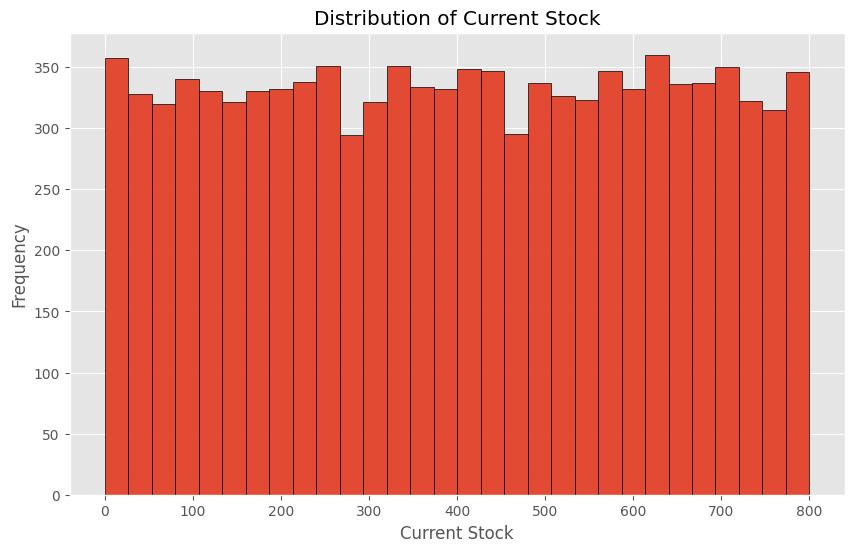

In [63]:
# ==========================================================
# STEP 15: CURRENT STOCK DISTRIBUTION
#
# Purpose:
#   Visualize how Current Stock is distributed across
#   all inventory records.
#
# Why?
#   This helps identify whether most products have
#   low, medium, or high stock levels.
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    inventory_clean["Current_Stock"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Current Stock")
plt.xlabel("Current Stock")
plt.ylabel("Frequency")

plt.show()

In [64]:
# ==========================================================
# STEP 16: INVENTORY OVERVIEW
#
# Purpose:
#   Calculate key inventory metrics that provide
#   a quick overview of the dataset.
# ==========================================================

print("Total Inventory Records :", len(inventory_clean))

print("Unique Products         :", inventory_clean["SKU"].nunique())

print("Average Current Stock   :", round(inventory_clean["Current_Stock"].mean(), 2))

print("Minimum Stock           :", inventory_clean["Current_Stock"].min())

print("Maximum Stock           :", inventory_clean["Current_Stock"].max())

Total Inventory Records : 10000
Unique Products         : 1000
Average Current Stock   : 400.42
Minimum Stock           : 0.0
Maximum Stock           : 800.0


### Key Findings

- Total inventory records analysed: 10,000

- 1,000 unique products are currently stored.

- Average inventory level is approximately 400 units.

- Some products currently have zero stock.

- Highest recorded inventory is 800 units.

In [65]:
# ==========================================================
# BUSINESS QUESTION 1
#
# Which warehouse currently stores
# the highest amount of inventory?
#
# Purpose:
# Compare inventory levels across warehouses
# to identify storage distribution.
# ==========================================================

warehouse_inventory = (
    inventory_clean
    .groupby("Warehouse")["Current_Stock"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_inventory

Warehouse
KK           538954.0
Melaka       513006.0
Kuching      500814.0
Johor        500385.0
Shah Alam    498728.0
Penang       498671.0
Kuantan      479569.0
Ipoh         474058.0
Name: Current_Stock, dtype: float64

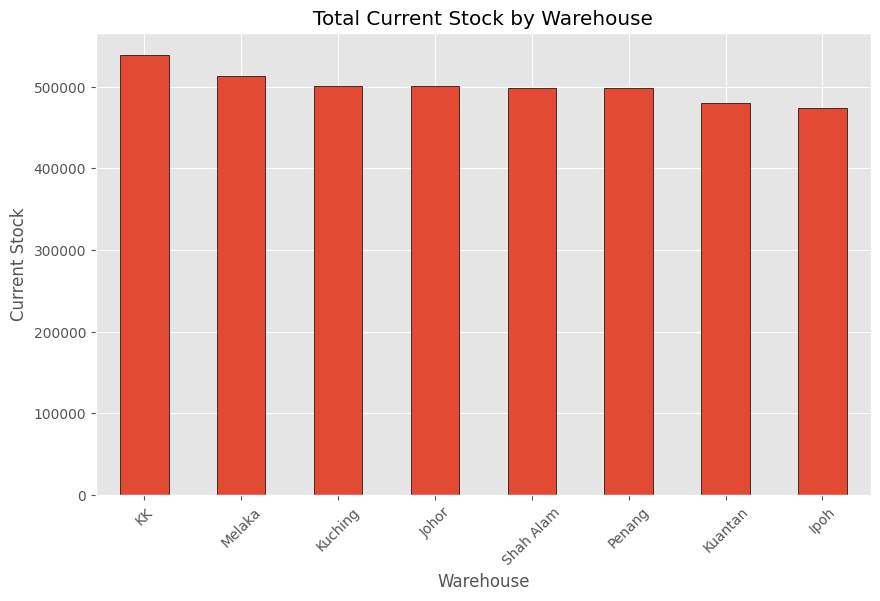

In [66]:
# ==========================================================
# VISUALIZATION
#
# Inventory by Warehouse
# ==========================================================

plt.figure(figsize=(10,6))

warehouse_inventory.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Total Current Stock by Warehouse")

plt.xlabel("Warehouse")

plt.ylabel("Current Stock")

plt.xticks(rotation=45)

plt.show()

## Business Insight

KK warehouse currently holds the highest inventory level (538,954 units), followed by Melaka (513,006 units) and Kuching (500,814 units).

However, a higher inventory level does not necessarily indicate better warehouse performance. The warehouse may be supporting higher customer demand, or it may be carrying excess inventory.

Further analysis should compare inventory levels with sales performance and inventory turnover to determine whether the inventory allocation is efficient.

In [73]:
# ==========================================================
# BUSINESS QUESTION 2
#
# Which products need to be reordered?
#
# Purpose:
#   Identify products where the current stock level
#   has fallen below the reorder threshold.
#
# Expected Output:
#   A list of products that require immediate replenishment.
# ==========================================================

reorder_products = inventory_clean[
    inventory_clean["Current_Stock"] < inventory_clean["Reorder_Level"]
]

print("Inventory records requiring reorder:", len(reorder_products))
print("Unique SKUs requiring reorder:", reorder_products["SKU"].nunique())
reorder_products

Inventory records requiring reorder: 768
Unique SKUs requiring reorder: 533


,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost
0,2025-04-01,KK,SKU0384,0.0,85,207,4,63.12
5,2024-12-05,Shah Alam,SKU0158,24.0,78,222,1,2.88
28,2025-10-08,Shah Alam,SKU0914,19.0,84,481,9,2.28
49,2024-03-28,Kuantan,SKU0653,19.0,56,385,9,2.28
72,2025-02-14,Kuching,SKU0624,38.0,69,533,9,4.56
...,...,...,...,...,...,...,...,...
9970,2024-12-29,Penang,SKU0395,59.0,98,295,8,7.08
9974,2025-08-26,Kuantan,SKU0260,51.0,57,421,6,6.12
9978,2024-11-23,Ipoh,SKU0223,63.0,75,435,2,7.56
9985,2024-11-16,Shah Alam,SKU0640,21.0,78,340,6,2.52


## Business Question

What products require immediate replenishment?

---

## Methodology

Products with Current Stock lower than the Reorder Level were identified using a conditional filter in Pandas.

---

## Findings

768 inventory records require reorder.

533 unique SKUs require reorder.

---

## Business Insight

More than half of the company's products are currently below the recommended reorder level, suggesting that inventory replenishment may not be keeping pace with demand. Several products have already reached zero stock, increasing the risk of stock-out events, lost sales, and reduced customer satisfaction if corrective actions are not taken promptly.

---

## Recommendation

- Prioritize replenishment for products with zero inventory.
- Review purchasing schedules for products consistently falling below the reorder level.
- Implement automated inventory alerts to notify the purchasing team before stock reaches critical levels.

In [ ]:
# ==========================================================
# BUSINESS QUESTION 3
#
# Which warehouse has the highest number of reorder-risk records?
#
# Purpose:
#   Identify warehouses with the most inventory records
#   below reorder level.
# ==========================================================

reorder_by_warehouse = (
    reorder_products
    .groupby("Warehouse")["SKU"]
    .count()
    .sort_values(ascending=False)
)

reorder_by_warehouse

Warehouse
KK           106
Kuching      106
Kuantan      103
Johor        100
Penang        95
Ipoh          91
Shah Alam     85
Melaka        82
Name: SKU, dtype: int64

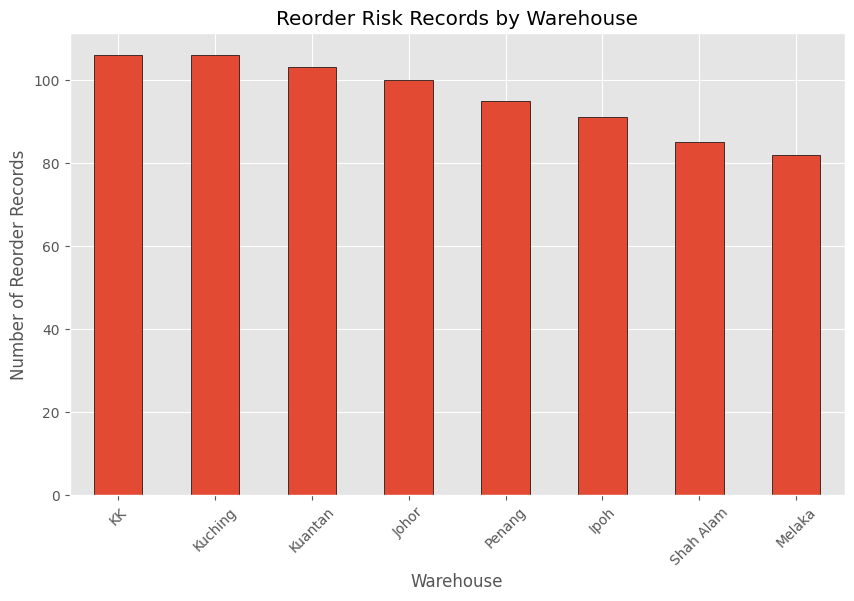

In [75]:
plt.figure(figsize=(10,6))

reorder_by_warehouse.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Reorder Risk Records by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Number of Reorder Records")
plt.xticks(rotation=45)

plt.show()

## Business Task 3: Reorder Risk by Warehouse

### Business Question
Which warehouse has the highest number of reorder-risk records?

### Methodology
Inventory records where Current_Stock is lower than Reorder_Level were grouped by warehouse.

### Findings

KK and Kuching warehouses recorded the highest number of inventory records below the reorder level, with 106 records each.

Melaka recorded the lowest reorder risk with 82 records.

---

### Business Insight

The higher number of reorder-risk records in KK and Kuching may indicate that these warehouses experience higher product demand or require more frequent inventory replenishment. However, additional sales and demand analysis is required before concluding that inventory management is inefficient.

---

### Recommendation

The inventory planning team should review replenishment schedules for KK and Kuching warehouses to ensure products are restocked before reaching critical inventory levels. Regular inventory monitoring and automated reorder alerts should also be implemented to reduce the risk of stock-outs.

In [77]:
# ==========================================================
# BUSINESS TASK 4
#
# Identify the Top 10 products that require
# the most urgent replenishment.
#
# Purpose:
#   Calculate the inventory shortage (Reorder Gap)
#   and prioritise products with the largest shortage.
# ==========================================================

reorder_products = reorder_products.copy()

# Create a new column to measure the inventory shortage
reorder_products["Reorder_Gap"] = (
    reorder_products["Reorder_Level"] -
    reorder_products["Current_Stock"]
)

# Sort by the largest shortage
top10_reorder = (
    reorder_products
    .sort_values("Reorder_Gap", ascending=False)
    .loc[:, ["Date", "Warehouse", "SKU", "Current_Stock", "Reorder_Level", "Reorder_Gap"]]
    .head(10)
)

top10_reorder

,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Reorder_Gap
1554,2024-05-02,Kuantan,SKU0154,0.0,97,97.0
3598,2025-03-31,Penang,SKU0248,3.0,99,96.0
8621,2025-12-06,KK,SKU0053,1.0,96,95.0
710,2025-05-02,Shah Alam,SKU0662,2.0,97,95.0
8287,2024-06-08,Shah Alam,SKU0895,5.0,99,94.0
2623,2024-01-19,Shah Alam,SKU0851,0.0,93,93.0
7806,2025-06-16,Ipoh,SKU0996,2.0,95,93.0
246,2025-05-20,Kuantan,SKU0557,5.0,97,92.0
8973,2024-03-31,Kuantan,SKU0277,7.0,99,92.0
2622,2024-05-24,Penang,SKU0130,2.0,93,91.0


## Business Question

Which products should be prioritised for replenishment?

---

## Methodology

A new metric called **Reorder Gap** was created by subtracting the Current Stock from the Reorder Level.

Products with the largest inventory shortage were ranked in descending order to identify the highest priority items.

---

## Findings

The analysis identified the Top 10 products with the largest inventory shortage.

The highest shortage recorded was **97 units**, indicating an urgent replenishment requirement.

---

## Business Insight

The top 10 highest-priority replenishment records have reorder gaps between **91 and 97 units**.

The most urgent case is **SKU0154 in Kuantan**, with **0 units in stock** against a reorder level of **97 units**. This indicates an immediate stock-out risk and should be prioritised for replenishment.

Several high-priority cases also appear in Shah Alam and Kuantan, suggesting that these warehouses may require closer monitoring of replenishment schedules.

---

## Recommendation

Prioritise purchasing for the Top 10 products based on the Reorder Gap.

Implement an automated inventory alert system to notify the purchasing team whenever inventory falls below the reorder threshold.

In [78]:
# ==========================================================
# BUSINESS TASK 5
#
# Add product details to reorder analysis.
#
# Purpose:
#   Merge reorder products with product information
#   so that SKU codes can be interpreted more clearly.
# ==========================================================

reorder_with_products = reorder_products.merge(
    products,
    on="SKU",
    how="left"
)

reorder_with_products.head()

,Date,Warehouse,SKU,Current_Stock,Reorder_Level,Max_Stock,Damaged_Qty,Holding_Cost,Reorder_Gap,Product_Name,Category,Brand,Unit_Cost,Selling_Price
0,2025-04-01,KK,SKU0384,0.0,85,207,4,63.12,85.0,Home_Product_384,Home,Nova,75.34,323.09
1,2024-12-05,Shah Alam,SKU0158,24.0,78,222,1,2.88,54.0,Home_Product_158,Home,Eco,288.43,321.44
2,2025-10-08,Shah Alam,SKU0914,19.0,84,481,9,2.28,65.0,Grocery_Product_914,Grocery,Nova,113.14,328.76
3,2024-03-28,Kuantan,SKU0653,19.0,56,385,9,2.28,37.0,Grocery_Product_653,Grocery,Smart,213.27,155.75
4,2025-02-14,Kuching,SKU0624,38.0,69,533,9,4.56,31.0,Grocery_Product_624,Grocery,Smart,231.45,23.19


In [79]:
# Check missing product details after merge
reorder_with_products[["SKU", "Product_Name", "Category", "Brand"]].isnull().sum()

SKU             0
Product_Name    0
Category        0
Brand           0
dtype: int64

In [80]:
top10_reorder_products = (
    reorder_with_products
    .sort_values("Reorder_Gap", ascending=False)
    .loc[:, [
        "Date", "Warehouse", "SKU", "Product_Name", "Category", "Brand",
        "Current_Stock", "Reorder_Level", "Reorder_Gap"
    ]]
    .head(10)
)

top10_reorder_products

,Date,Warehouse,SKU,Product_Name,Category,Brand,Current_Stock,Reorder_Level,Reorder_Gap
112,2024-05-02,Kuantan,SKU0154,Sports_Product_154,Sports,Nova,0.0,97,97.0
288,2025-03-31,Penang,SKU0248,Beauty_Product_248,Beauty,Alpha,3.0,99,96.0
658,2025-12-06,KK,SKU0053,Home_Product_53,Home,Prime,1.0,96,95.0
50,2025-05-02,Shah Alam,SKU0662,Pet_Product_662,Pet,Eco,2.0,97,95.0
631,2024-06-08,Shah Alam,SKU0895,Home_Product_895,Home,Eco,5.0,99,94.0
193,2024-01-19,Shah Alam,SKU0851,Stationery_Product_851,Stationery,Eco,0.0,93,93.0
592,2025-06-16,Ipoh,SKU0996,Beauty_Product_996,Beauty,Alpha,2.0,95,93.0
17,2025-05-20,Kuantan,SKU0557,Electronics_Product_557,Electronics,Nova,5.0,97,92.0
685,2024-03-31,Kuantan,SKU0277,Home_Product_277,Home,Smart,7.0,99,92.0
192,2024-05-24,Penang,SKU0130,Beauty_Product_130,Beauty,Zen,2.0,93,91.0


## Business Insight

After merging reorder data with product details, the most urgent replenishment item is **Sports_Product_154** under the **Sports** category at the **Kuantan warehouse**, with a reorder gap of **97 units**.

The Top 10 priority list includes products from multiple categories such as Sports, Beauty, Home, Pet, Stationery, and Electronics. This suggests that reorder risk is not limited to one product category only.

## Recommendation

The purchasing team should prioritise the Top 10 products based on reorder gap, starting with items that have zero or near-zero current stock. Category-level analysis should be performed next to identify whether certain categories are consistently facing replenishment issues.

In [88]:
# ==========================================================
# BUSINESS TASK 6
#
# Which product categories have the highest reorder risk?
#
# Purpose:
#   Get the total gap products for each category and
#   summarize it in descending order.
# ==========================================================

total_reorder_gap = (
    reorder_with_products
    .groupby("Category")["Reorder_Gap"]
    .sum()
    .sort_values(ascending=False)
)

total_reorder_gap

Category
Home           4309.0
Beauty         3879.0
Automotive     3496.0
Sports         3325.0
Grocery        3209.0
Stationery     2939.0
Electronics    2781.0
Pet            2752.0
Name: Reorder_Gap, dtype: float64

In [89]:
# ==========================================================
# BUSINESS TASK 7
#
# Which product category has the highest average
# reorder gap?
#
# Purpose:
#   Compare the average inventory shortage across
#   different product categories.
#
# Why?
#   Total reorder gap may be influenced by the number
#   of products in each category.
# ==========================================================

average_gap_category = (
    reorder_with_products
    .groupby("Category")["Reorder_Gap"]
    .mean()
    .sort_values(ascending=False)
)

average_gap_category

Category
Pet            37.698630
Home           36.829060
Sports         36.538462
Automotive     35.673469
Beauty         34.945946
Grocery        33.082474
Electronics    32.337209
Stationery     30.936842
Name: Reorder_Gap, dtype: float64

In [90]:
reorder_records_category = (
    reorder_with_products
    .groupby("Category")["SKU"]
    .count()
)

category_reorder_summary = pd.concat(
    [total_reorder_gap, average_gap_category, reorder_records_category],
    axis=1
)

category_reorder_summary.columns = [
    "Total_Reorder_Gap",
    "Average_Reorder_Gap",
    "Reorder_Records"
]

category_reorder_summary = category_reorder_summary.sort_values(
    "Total_Reorder_Gap",
    ascending=False
)

category_reorder_summary

,Total_Reorder_Gap,Average_Reorder_Gap,Reorder_Records
Category,,,
Home,4309.0,36.829060,117
Beauty,3879.0,34.945946,111
Automotive,3496.0,35.673469,98
Sports,3325.0,36.538462,91
Grocery,3209.0,33.082474,97
Stationery,2939.0,30.936842,95
Electronics,2781.0,32.337209,86
Pet,2752.0,37.698630,73


The Home category recorded the highest total reorder gap (4,309 units). However, it also contains the largest number of reorder records (117), which contributes to the higher total shortage.

Interestingly, the Pet category recorded the highest average reorder gap (37.70 units per reorder record), despite having fewer reorder records (73). This suggests that individual products within the Pet category tend to experience more severe inventory shortages.

Therefore, inventory planning should consider both total shortage and average shortage instead of relying on a single metric.